<a href="https://colab.research.google.com/github/CrUz-035/Proyecto-Reconocimiento-Facial/blob/main/Modelo_Prentrenado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Instalar librerías necesarias
from google.colab import userdata
!pip install kaggle mlflow dagshub --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import userdata

# Configurar credenciales de Kaggle
os.environ["KAGGLE_USERNAME"] =userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

import kagglehub

# Descargar dataset de CelebA
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")


Using Colab cache for faster access to the 'celeba-dataset' dataset.


In [ ]:
#Leer atributos y tomar solo 20000 imágenes como ejemplo
atributos = os.path.join(path, 'list_attr_celeba.csv')
atributos_pd = pd.read_csv(atributos)

celeb = pd.DataFrame({
    "image_path": atributos_pd["image_id"].head(20000).apply(lambda x: os.path.join(path, 'img_align_celeba', 'img_align_celeba', x)),
    "label": 0
})
len(celeb)

20000

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

drive_ruta = '/content/drive/MyDrive/Colab Notebooks/Dataset'
drive_imgs = [os.path.join(drive_ruta, f) for f in os.listdir(drive_ruta)
              if f.lower().endswith((".jpg", ".png", ".jpeg"))]  # solo formatos soportados

df_drive = pd.DataFrame({
    "image_path": drive_imgs,
    "label": 1
})
len(df_drive)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


2057

In [ ]:
# Combinar datasets
data = pd.concat([celeb, df_drive], ignore_index=True)

# Separar Train/Test
train_df, test_df = train_test_split(
    data,
    test_size=0.2,
    stratify=data["label"],
    random_state=42
)

# Asegurar tipo entero en etiquetas
train_df["label"] = train_df["label"].astype(int)
test_df["label"] = test_df["label"].astype(int)


In [ ]:
# Generadores de imágenes
datagen = ImageDataGenerator(rescale=1./255)
datagen_aug = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    zoom_range=0.2,
    rescale=1./255
)

# Generador combinado
def combined_generator(train_df, batch_size=64, target_size=(150,150)):
    df0 = train_df[train_df["label"]==0]
    df1 = train_df[train_df["label"]==1]

    gen0 = datagen.flow_from_dataframe(
        df0, x_col="image_path", y_col="label",
        target_size=target_size, batch_size=64,
        class_mode="raw", shuffle=True
    )
    gen1 = datagen_aug.flow_from_dataframe(
        df1, x_col="image_path", y_col="label",
        target_size=target_size, batch_size=64,
        class_mode="raw", shuffle=True
    )

    while True:
        x0, y0 = next(gen0)
        x1, y1 = next(gen1)

        # Tomar mínimo batch size de ambos para evitar concatenación desigual
        min_len = min(len(x0), len(x1))
        x = np.concatenate([x0[:min_len], x1[:min_len]], axis=0)
        y = np.concatenate([y0[:min_len], y1[:min_len]], axis=0)

        idx = np.arange(len(x))
        np.random.shuffle(idx)
        yield x[idx], y[idx]

train_generator = combined_generator(train_df)


In [ ]:
test_generator = datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=(150,150),
    batch_size=64,
    class_mode="raw",
    shuffle=False
)


Found 4412 validated image filenames.


In [ ]:
# Cargar modelo preentrenado (solo CelebA)
model = keras.models.load_model("/content/Entrenamiento_rostro (3).h5")
model.trainable = False  # congelar capas preentrenadas

# Añadir clasificador binario
x = model.layers[-2].output
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_binaria = models.Model(inputs=model.input, outputs=outputs)
model_binaria.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=0.001),
    metrics=["accuracy"]
)

model_binaria.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 150, 150,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 150, 150,  │     18,496 │ conv2d_18[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 75, 75,    │          0 │ conv2d_19[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 75, 75,    │        256 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 75, 75,    │          0 │ max_pooling2d_4[… │
│                     │ 64)               │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 75, 75,    │     27,696 │ add_6[0][0]       │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 75, 75,    │     41,568 │ conv2d_21[0][0]   │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 38, 38,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 38, 38,    │      6,240 │ add_6[0][0]       │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 38, 38,    │          0 │ max_pooling2d_5[… │
│                     │ 96)               │            │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 38, 38,    │     55,360 │ add_7[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 38, 38,    │     73,856 │ conv2d_24[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 38, 38,    │     12,416 │ add_7[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 38, 38,    │          0 │ conv2d_25[0][0],  │
│                     │ 128)              │            │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_8[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ global_average_p

 Total params: 270,065 (1.03 MB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 236,784 (924.94 KB)

In [ ]:
import mlflow
from getpass import getpass

mlflow.tensorflow.autolog()

REPO_NAME = "Prentrenado"
REPO_OWNER = "CrUz-035"
USER_NAME = "CrUz-035"

os.environ['MLFLOW_TRACKING_USERNAME'] = USER_NAME
os.environ['MLFLOW_TRACKING_PASSWORD'] =userdata.get('TOKEN')

mlflow.set_tracking_uri(f'https://dagshub.com/{REPO_OWNER}/{REPO_NAME}.mlflow')
mlflow.set_experiment("Prentrenado")


<Experiment: artifact_location='mlflow-artifacts:/19a67a147c774b579677bb83b0f18935', creation_time=1773605804249, experiment_id='0', last_update_time=1773605804249, lifecycle_stage='active', name='Prentrenado', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', mode='min', restore_best_weights=True, patience=3, verbose=1),
    ModelCheckpoint(filepath="Prentrenamiento.h5", monitor='val_loss', save_best_only=True, verbose=1)
]

with mlflow.start_run(run_name="Prentrenamiento"):
    history = model_binaria.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=6,
    validation_data=test_generator,
    validation_steps=len(test_generator),
    callbacks=callbacks
)

    mlflow.log_metric("final_val_accuracy", max(history.history["val_accuracy"]))
    mlflow.log_metric("final_val_loss", min(history.history["val_loss"]))
    mlflow.log_artifact("Prentrenamiento.h5")

Found 15999 validated image filenames.
Found 1646 validated image filenames.


2026/03/16 03:22:30 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'generator'>. Dataset logging skipped.
2026/03/16 03:22:30 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DataFrameIterator'>. Dataset logging skipped.


Epoch 1/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8815 - loss: 0.3091
Epoch 1: val_loss improved from None to 0.18860, saving model to Prentrenamiento.h5



Epoch 1: finished saving model to Prentrenamiento.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 558s 6s/step - accuracy: 0.9073 - loss: 0.2446 - val_accuracy: 0.9166 - val_loss: 0.1886
Epoch 2/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9203 - loss: 0.1986
Epoch 2: val_loss did not improve from 0.18860
100/100 ━━━━━━━━━━━━━━━━━━━━ 471s 5s/step - accuracy: 0.9256 - loss: 0.1926 - val_accuracy: 0.9116 - val_loss: 0.2062
Epoch 3/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9318 - loss: 0.1812
Epoch 3: val_loss improved from 0.18860 to 0.15775, saving model to Prentrenamiento.h5


...

100/100 ━━━━━━━━━━━━━━━━━━━━ 444s 4s/step - accuracy: 0.9341 - loss: 0.1786 - val_accuracy: 0.9327 - val_loss: 0.1578
Epoch 4/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9343 - loss: 0.1780
Epoch 4: val_loss did not improve from 0.15775
100/100 ━━━━━━━━━━━━━━━━━━━━ 423s 4s/step - accuracy: 0.9344 - loss: 0.1774 - val_accuracy: 0.9252 - val_loss: 0.1804
Epoch 5/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9398 - loss: 0.1599
Epoch 5: val_loss improved from 0.15775 to 0.14483, saving model to Prentrenamiento.h5



Epoch 5: finished saving model to Prentrenamiento.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 435s 4s/step - accuracy: 0.9361 - loss: 0.1669 - val_accuracy: 0.9388 - val_loss: 0.1448
Epoch 6/6
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9369 - loss: 0.1619
Epoch 6: val_loss did not improve from 0.14483
100/100 ━━━━━━━━━━━━━━━━━━━━ 436s 4s/step - accuracy: 0.9367 - loss: 0.1626 - val_accuracy: 0.9322 - val_loss: 0.1578
Restoring model weights from the end of the best epoch: 5.


2026/03/16 04:08:43 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: Cannot log input example or model signature for input with type <class 'generator'>. TensorFlow Keras autologging can only log input examples and model signatures for the following input types: numpy.ndarray, dict[string -> numpy.ndarray], tensorflow.keras.utils.Sequence, and tensorflow.data.Dataset (TensorFlow >= 2.1.0 required)
2026/03/16 04:08:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/16 04:08:47 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


🏃 View run Prentrenamiento at: https://dagshub.com/CrUz-035/Prentrenado.mlflow/#/experiments/0/runs/9407b80aae2e437da183556901391468
🧪 View experiment at: https://dagshub.com/CrUz-035/Prentrenado.mlflow/#/experiments/0


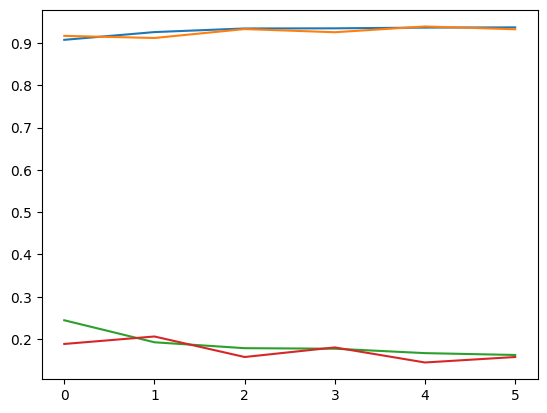

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
# Cargar modelo
model = keras.models.load_model("/content/Prentrenamiento.h5")

for layer in model.layers[:11]:  #índice 10
    layer.trainable = False


model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.RMSprop(learning_rate=0.00001),
    metrics=["accuracy"]
)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 150, 150,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 150, 150,  │     18,496 │ conv2d_18[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 75, 75,    │          0 │ conv2d_19[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 75, 75,    │        256 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 75, 75,    │          0 │ max_pooling2d_4[… │
│                     │ 64)               │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 75, 75,    │     27,696 │ add_6[0][0]       │
│                     │ 48)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 75, 75,    │     41,568 │ conv2d_21[0][0]   │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 38, 38,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 38, 38,    │      6,240 │ add_6[0][0]       │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 38, 38,    │          0 │ max_pooling2d_5[… │
│                     │ 96)               │            │ conv2d_23[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 38, 38,    │     55,360 │ add_7[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 38, 38,    │     73,856 │ conv2d_24[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 38, 38,    │     12,416 │ add_7[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 38, 38,    │          0 │ conv2d_25[0][0],  │
│                     │ 128)              │            │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ add_8[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ global_average_p

 Total params: 270,065 (1.03 MB)

 Trainable params: 33,281 (130.00 KB)

 Non-trainable params: 236,784 (924.94 KB)

In [ ]:
import mlflow
from getpass import getpass

mlflow.tensorflow.autolog()

REPO_NAME = "Fine_tunning"
REPO_OWNER = "CrUz-035"
USER_NAME = "CrUz-035"

os.environ['MLFLOW_TRACKING_USERNAME'] = USER_NAME
os.environ['MLFLOW_TRACKING_PASSWORD'] =userdata.get('TOKEN')

mlflow.set_tracking_uri(f'https://dagshub.com/{REPO_OWNER}/{REPO_NAME}.mlflow')
mlflow.set_experiment("Finetunning")


<Experiment: artifact_location='mlflow-artifacts:/2f867d518659459494da5387bb3bd0d1', creation_time=1773624744297, experiment_id='1', last_update_time=1773624744297, lifecycle_stage='active', name='Finetunning', tags={}, workspace='default'>

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', mode='min', restore_best_weights=True, patience=10, verbose=1),
    ModelCheckpoint(filepath="Prentrenamiento.h5", monitor='val_loss', save_best_only=True, verbose=1)
]

with mlflow.start_run(run_name="finetunning"):
    history = model.fit(
        x=train_generator,
        steps_per_epoch=100,
        epochs=5,
        validation_data=test_generator,
        callbacks=callbacks
    )

    mlflow.log_metric("final_val_accuracy", max(history.history["val_accuracy"]))
    mlflow.log_metric("final_val_loss", min(history.history["val_loss"]))
    mlflow.log_artifact("finetunning.h5")


plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

2026/03/16 04:20:39 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'generator'>. Dataset logging skipped.
2026/03/16 04:20:39 WARNING mlflow.tensorflow: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DataFrameIterator'>. Dataset logging skipped.


Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9360 - loss: 0.1663
Epoch 1: val_loss improved from None to 0.14938, saving model to Prentrenamiento.h5



Epoch 1: finished saving model to Prentrenamiento.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 434s 4s/step - accuracy: 0.9351 - loss: 0.1656 - val_accuracy: 0.9374 - val_loss: 0.1494
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9387 - loss: 0.1595
Epoch 2: val_loss did not improve from 0.14938
100/100 ━━━━━━━━━━━━━━━━━━━━ 425s 4s/step - accuracy: 0.9381 - loss: 0.1607 - val_accuracy: 0.9368 - val_loss: 0.1517
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9386 - loss: 0.1628
Epoch 3: val_loss did not improve from 0.14938
100/100 ━━━━━━━━━━━━━━━━━━━━ 414s 4s/step - accuracy: 0.9369 - loss: 0.1671 - val_accuracy: 0.9365 - val_loss: 0.1525
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9380 - loss: 0.1596
Epoch 4: val_loss did not improve from 0.14938
100/100 ━━━━━━━━━━━━━━━━━━━━ 401s 4s/step - accuracy: 0.9384 - loss: 0.1590 - val_accuracy: 0.9354 - val_loss: 0.1552
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9362 - loss: 0.1669
Epoch 5: val_loss did not improve from 0.14938
100/

2026/03/16 04:56:07 WARNING mlflow.tensorflow: Failed to infer model signature: could not sample data to infer model signature: tuple index out of range
2026/03/16 04:56:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/16 04:56:10 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


🏃 View run finetunning at: https://dagshub.com/CrUz-035/Fine_tunning.mlflow/#/experiments/1/runs/de945d5b4a5346708da3102607ced928
🧪 View experiment at: https://dagshub.com/CrUz-035/Fine_tunning.mlflow/#/experiments/1


FileNotFoundError: [Errno 2] No such file or directory: 'finetunning.h5'

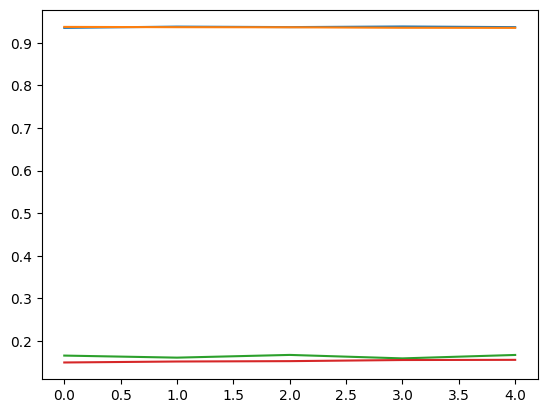

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

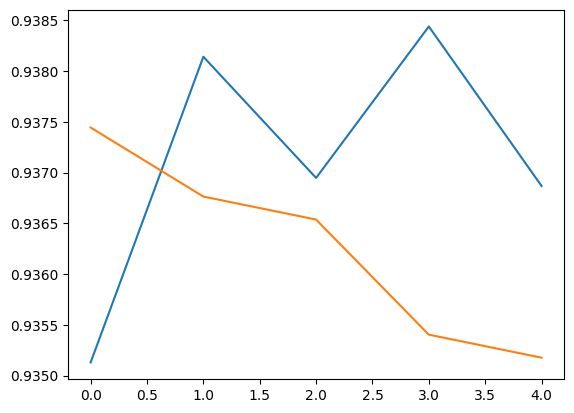

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


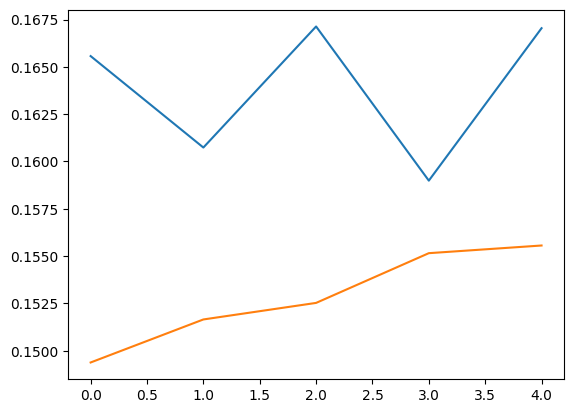

In [ ]:

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image
import cv2
from IPython.display import display, Javascript
from google.colab.patches import cv2_imshow

ruta_modelo = "/content/latest_checkpoint (3).h5"


uploaded = files.upload()
nombre_archivo_imagen = list(uploaded.keys())[0]
modelo = keras.models.load_model(ruta_modelo)


def preprocesar_imagen(ruta_imagen, mostrar=True):
    # Cargar imagen
    img = image.load_img(ruta_imagen, target_size=(150, 150))

    # Convertir a array
    img_array = image.img_to_array(img)

    # Normalizar
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title("Imagen de prueba")
    plt.axis('off')
    plt.show()
    return img_array # Added proper indentation for return

def predecir_rostro(modelo, img_array, nombre_archivo="", umbral=0.5):
    # Predicción
    prediccion = modelo.predict(img_array, verbose=0)[0][0]

    print(f"Valor de predicción: {prediccion:.4f}")

img_to_predict = preprocesar_imagen(nombre_archivo_imagen)
predecir_rostro(modelo, img_to_predict)